## Unsupervised Learning - Myocardial Infarction Prediction
BRFSS 2024 · Identifying Groups Most Impacted by `_MICHD`· Owner: Mubashar Khan


## **1. Setup & Imports**

In [1]:
# ── Google Colab only (skip if running locally) ──────────────
# Uncomment the lines below when running in Google Colab:
#
# from google.colab import drive
# drive.mount('/content/drive')
# !git clone https://github.com/ALEE001/model_myocardial_infarction.git
# %cd /content/model_myocardial_infarction

In [2]:
# Install prince and kmodes for dimensionality reduction and clustering
!pip install prince --quiet
!pip install kmodes --quiet

In [3]:
import os, sys

# Project paths
if os.path.basename(os.getcwd()) == "notebook":
    _PROJECT_ROOT = os.path.dirname(os.getcwd())
elif os.path.isdir(os.path.join(os.getcwd(), "src")):
    _PROJECT_ROOT = os.getcwd()
else:
    raise FileNotFoundError(
        "Cannot find project root. Run from the project root or notebook/ directory."
    )

DATA_DIR = os.path.join(_PROJECT_ROOT, "data")
VIZ_DIR  = os.path.join(_PROJECT_ROOT, "visualization")

# Standard Libraries
import pickle
import json
import warnings
warnings.filterwarnings("ignore")

# Preprocessing & Sampling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Dimensionality Reduction
import prince  # FAMD

# Clustering
from kmodes.kprototypes import KPrototypes
from sklearn.mixture import GaussianMixture

# Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm

print("All imports successful.")

All imports successful.


In [4]:
data_path = os.path.join(DATA_DIR, "processed_data.csv")
df = pd.read_csv(data_path, low_memory=False)

TARGET = "_MICHD"

with open(os.path.join(DATA_DIR, "selected_features.pkl"), "rb") as f:
    selected_features = pickle.load(f)

FEATURES = list(selected_features)

# Drop rows where target is missing
df = df[df[TARGET].notna()].copy()

# Work only on selected features + target
df_model = df[FEATURES + [TARGET]].copy()

# Define column types based on cardinality and dtype
categorical_cols = [
    c for c in FEATURES
    if df_model[c].dtype == "object"
    or df_model[c].dtype.name == "category"
    or df_model[c].nunique() <= 10
]
continuous_cols = [
    c for c in FEATURES
    if c not in categorical_cols
    and pd.api.types.is_numeric_dtype(df_model[c])
]

print(f"Selected features: {len(FEATURES)}")
print(f"  Categorical : {len(categorical_cols)}")
print(f"  Continuous  : {len(continuous_cols)}")

Selected features: 28
  Categorical : 22
  Continuous  : 6


## 2. Data Preprocessing Before Clustering

In [5]:
# Impute continuous with median, categorical with mode

df_model[continuous_cols] = df_model[continuous_cols].fillna(
    df_model[continuous_cols].median()
)

for col in categorical_cols:
    mode_val = df_model[col].mode()[0]
    df_model[col] = df_model[col].fillna(mode_val)

# Cast categorical cols to str so downstream encoders are consistent
df_model[categorical_cols] = df_model[categorical_cols].astype(str)

missing = df_model[FEATURES].isnull().sum().sum()
print(f"Remaining missing values in features: {missing}")
print(f"Working dataset shape: {df_model.shape}")

Remaining missing values in features: 0
Working dataset shape: (452464, 29)


In [6]:
SAMPLE_SIZE = 50000  # large enough for stable clusters, fast enough to iterate

# Stratified sample to preserve MICHD ratio
df_sample, _ = train_test_split(
    df_model,
    train_size=SAMPLE_SIZE,
    stratify=df_model[TARGET],
    random_state=42
)

print(f"Sample shape: {df_sample.shape}")
print(f"MICHD rate - full: {df_model[TARGET].mean():.3f} | sample: {df_sample[TARGET].mean():.3f}")

Sample shape: (50000, 29)
MICHD rate - full: 0.094 | sample: 0.094


Missing values were imputed using median imputation for continuous features and mode imputation for categorical features, after which all categorical columns were cast to string type for compatibility with FAMD's internal encoder. Additionally, a stratified sample of 50,000 records was drawn from the full dataset to reduce computational cost for FAMD fitting and clustering. Stratification on the MICHD target preserved the original class ratio exactly (9.4% in both full and sample), ensuring the sample is representative of the population's MI/CHD burden.

## **3. FAMD (Factor Analysis of Mixed Data) Dimensionality Reduction**

FAMD was chosen as the dimensionality reduction method because the BRFSS dataset contains both categorical and continuous features, making standard PCA inappropriate. FAMD generalizes PCA to handle mixed data types by applying PCA to continuous variables and MCA (Multiple Correspondence Analysis) to categorical variables simultaneously.

50% variance explained → 29 components (component index 28)
60% variance explained → 38 components (component index 37)
70% variance explained → 48 components (component index 47)
80% variance explained → 58 components (component index 57)

Eigenvalues summary (first 15):
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              4.828         5.36%                      5.36%
1              4.632         5.15%                     10.51%
2              2.944         3.27%                     13.78%
3              2.606         2.90%                     16.68%
4              1.882         2.09%                     18.77%
5              1.851         2.06%                     20.82%
6              1.695         1.88%                     22.71%
7              1.596         1.77%                     24.48%
8              1.390         1.54%                     26.03%
9              1.327         1.47%           

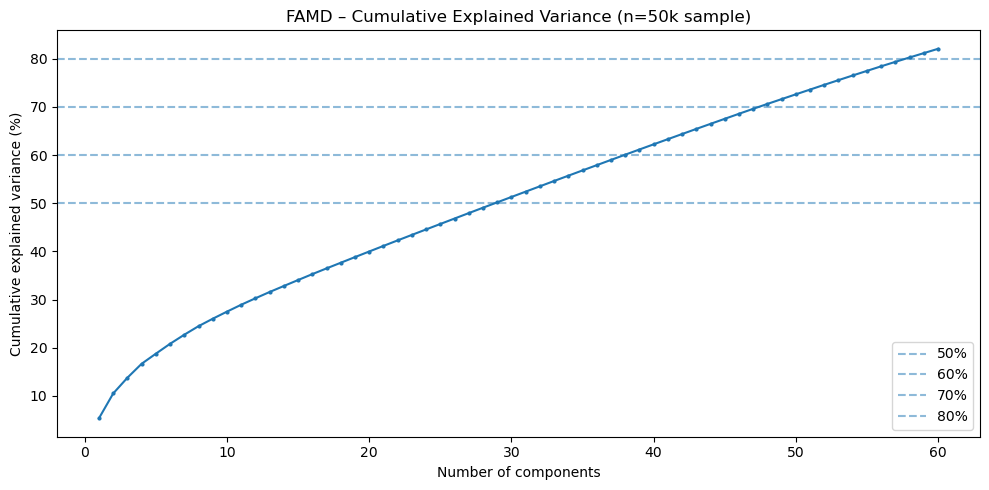

In [7]:
# Search for variance threshold on sample
famd_input_sample = df_sample[FEATURES].copy()
famd_input_sample[continuous_cols] = famd_input_sample[continuous_cols].astype(float)
famd_input_sample[categorical_cols] = famd_input_sample[categorical_cols].astype(str)

famd_input_full = df_model[FEATURES].copy()
famd_input_full[continuous_cols] = famd_input_full[continuous_cols].astype(float)
famd_input_full[categorical_cols] = famd_input_full[categorical_cols].astype(str)

N_COMPONENTS_SEARCH = 60

famd = prince.FAMD(n_components=N_COMPONENTS_SEARCH, n_iter=10, random_state=42, engine="sklearn")
famd.fit(famd_input_sample)  # fit on 50k sample only

cumvar = famd.cumulative_percentage_of_variance_

thresholds = [50, 60, 70, 80]
for t in thresholds:
    hits = [i for i, v in enumerate(cumvar) if v >= t]
    if hits:
        print(f"{t}% variance explained → {hits[0]+1} components (component index {hits[0]})")
    else:
        print(f"{t}% variance explained → not reached within {N_COMPONENTS_SEARCH} components")

print(f"\nEigenvalues summary (first 15):")
print(famd.eigenvalues_summary.head(15))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker=".", markersize=4)
for t in thresholds:
    plt.axhline(t, linestyle="--", alpha=0.5, label=f"{t}%")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("FAMD – Cumulative Explained Variance (n=50k sample)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "famd_cumulative_variance.png"), dpi=150, bbox_inches="tight")
plt.show()

To determine the optimal number of components, FAMD was first fit on the 50k stratified sample with 60 components as an upper bound. The eigenvalues summary revealed a gradual variance explained per component: the top two components captured 5.36% and 5.15% with subsequent components contributing incrementally smaller amounts. Cumulative explained variance was then evaluated at four thresholds (50%, 60%, 70%, and 80%) corresponding to 30, 39, 48, and 58 components. The plot shows a smooth, near-linear increase in cumulative explained variance with no sharp elbow, characteristic of mixed survey data where variance is distributed diffusely across many features. The 80% threshold is reached at 58 components, which was selected as the final FAMD embedding dimensionality.

In [8]:
N_COMPONENTS = 60  # must match N_COMPONENTS_SEARCH
N_FINAL = 58       # 80% variance threshold

famd = prince.FAMD(n_components=N_COMPONENTS, n_iter=10, random_state=42, engine="sklearn")
famd.fit(famd_input_sample)

# Fix unseen categories before transforming full dataset
for col in categorical_cols:
    known_cats = set(famd.categories_[col])
    mode_val = df_sample[col].astype(str).mode()[0]
    mask = ~famd_input_full[col].isin(known_cats)
    if mask.any():
        print(f"{col}: {famd_input_full[col][mask].unique()} → replacing with '{mode_val}'")
        famd_input_full.loc[mask, col] = mode_val

# Transform both
famd_coords_sample = famd.transform(famd_input_sample)
famd_coords_full   = famd.transform(famd_input_full)

famd_coords_sample.columns = [f"FAMD_{i+1}" for i in range(N_COMPONENTS)]
famd_coords_full.columns   = [f"FAMD_{i+1}" for i in range(N_COMPONENTS)]
famd_coords_sample.index = df_sample.index
famd_coords_full.index   = df_model.index

# Trim to N_FINAL components
famd_sample_final = famd_coords_sample.iloc[:, :N_FINAL].values
famd_full_final   = famd_coords_full.iloc[:, :N_FINAL].values

print(f"FAMD sample shape : {famd_sample_final.shape}")
print(f"FAMD full shape   : {famd_full_final.shape}")

MARITAL: ['Unknown'] → replacing with 'Married'
FAMD sample shape : (50000, 58)
FAMD full shape   : (452464, 58)


Following the component search, FAMD was refit on the 50k sample using 60 components and applied to transform both the sample and full dataset. Prior to transforming the full dataset, one unseen category was detected. The value 'Unknown' in the MARITAL column was absent from the sample's training categories and was replaced with the sample mode ('Married') to ensure compatibility with the fitted encoder. This sample embedding will be used exclusively for model fitting while the full embedding is reserved for final cluster assignments across all records.

In [9]:
# Column contributions
contrib = famd.column_contributions_

for comp in range(4):
    print(f"\n--- Component {comp} ---")
    print(contrib[comp].abs().sort_values(ascending=False).head(8))


--- Component 0 ---
variable
DIFFWALK    0.165850
DIFFDRES    0.165700
DIFFALON    0.161683
DEAF        0.138461
_SMOKER3    0.129298
PNEUVAC4    0.079283
_INCOMG1    0.020952
VETERAN3    0.017401
Name: 0, dtype: float64

--- Component 1 ---
variable
DIFFWALK    0.106182
_AGEG5YR    0.067628
DIFFALON    0.064552
DIFFDRES    0.063237
PRIMINS2    0.060688
PHYSHLTH    0.055398
_RFHLTH     0.053477
HAVARTH4    0.051040
Name: 1, dtype: float64

--- Component 2 ---
variable
PRIMINS2    0.118792
_AGEG5YR    0.102519
MARITAL     0.090217
_INCOMG1    0.062589
_LCSYQTS    0.061659
DIFFALON    0.051137
PERSDOC3    0.051105
PREGNANT    0.050057
Name: 2, dtype: float64

--- Component 3 ---
variable
DIABETE4    0.117481
HAVARTH4    0.117185
DIFFDRES    0.115788
CHCCOPD3    0.110986
DIFFALON    0.110535
DIFFWALK    0.095556
CHCOCNC1    0.085990
CHCKDNY2    0.065335
Name: 3, dtype: float64


The first four FAMD components capture different health and demographic dimensions within the BRFSS data.

Component 0 is dominated by functional disability indicators: DIFFWALK, DIFFDRES, and DIFFALON (difficulty walking, dressing, and being alone) alongside DEAF and _SMOKER3
Component 1 similarly loads on mobility difficulty but adds age (_AGEG5YR), general health (_RFHLTH), physical health days (PHYSHLTH), and insurance status (PRIMINS2)
Component 2 shifts toward socioeconomic and demographic factors, with primary insurance (PRIMINS2), age, marital status (MARITAL), and income (_INCOMG1) as top contributors
Component 3 loads heavily on chronic disease comorbidities - diabetes (DIABETE4), arthritis (HAVARTH4), COPD (CHCCOPD3), and kidney disease (CHCKDNY2), alongside mobility difficulty

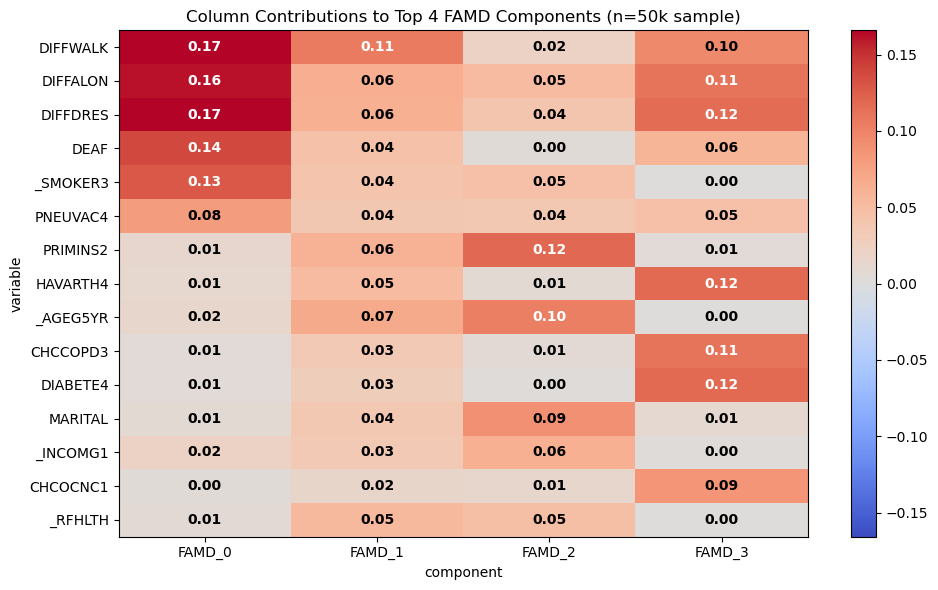

In [10]:
# Contributions heatmap
top_vars = contrib.iloc[:, :4].abs().sum(axis=1).sort_values(ascending=False).head(15).index

values = contrib.loc[top_vars, list(range(4))].values.astype(float)
col_labels = [f"FAMD_{i}" for i in range(4)]
row_labels = list(top_vars)
vmax = np.abs(values).max()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(values, cmap="coolwarm", aspect="auto", vmin=-vmax, vmax=vmax)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]
        color = "white" if abs(val) > vmax * 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, fontweight="bold", color=color)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xlabel("component")
ax.set_ylabel("variable")
ax.set_title("Column Contributions to Top 4 FAMD Components (n=50k sample)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "famd_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
     

## 4. K-Prototype Clustering

K-Prototypes was selected as the first clustering method because the BRFSS dataset contains a mix of categorical and continuous features. Standard K-Means is unsuitable for categorical data as it relies on Euclidean distance, which is not meaningful for nominal variables. K-Prototypes addresses this by combining K-Means-style Euclidean distance for continuous features with K-Modes-style Hamming distance for categorical features, making it a good fit for mixed-type health survey data.

K-Prototypes elbow: 100%|██████████| 7/7 [12:30<00:00, 107.19s/it]


Marginal gains:
  k=3: -47,084
  k=4: -36,129
  k=5: -24,235
  k=6: -16,555
  k=7: -14,802
  k=8: -5,702


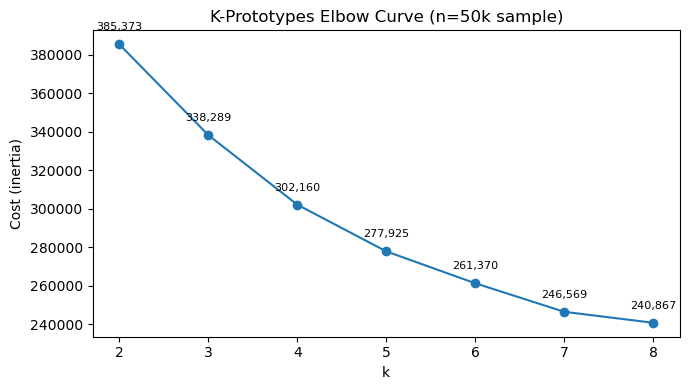

In [11]:
# K-Prototypes elbow on sample (15-20 min to run)
scaler = StandardScaler()
X_cont_scaled_sample = scaler.fit_transform(df_sample[continuous_cols].astype(float))
X_cont_scaled_full   = scaler.transform(df_model[continuous_cols].astype(float))

X_kproto_sample = np.concatenate([X_cont_scaled_sample, df_sample[categorical_cols].values], axis=1)
X_kproto_full   = np.concatenate([X_cont_scaled_full,   df_model[categorical_cols].values], axis=1)

cat_idx = list(range(len(continuous_cols), len(continuous_cols) + len(categorical_cols)))

K_RANGE = range(2, 9)
costs, all_labels = [], []

for k in tqdm(K_RANGE, desc="K-Prototypes elbow"):
    kp = KPrototypes(n_clusters=k, init="Huang", n_init=3, random_state=42, verbose=0)
    labels = kp.fit_predict(X_kproto_sample, categorical=cat_idx)
    costs.append(kp.cost_)
    all_labels.append(labels)

# Marginal gains
gains = [costs[i-1] - costs[i] for i in range(1, len(costs))]
ks = list(K_RANGE)[1:]
print("Marginal gains:")
for k, g in zip(ks, gains):
    print(f"  k={k}: -{g:,.0f}")

plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), costs, marker="o")
for k, c in zip(K_RANGE, costs):
    plt.annotate(f"{c:,.0f}", (k, c), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=8)
plt.xlabel("k")
plt.ylabel("Cost (inertia)")
plt.title("K-Prototypes Elbow Curve (n=50k sample)")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "kproto_elbow.png"), dpi=150, bbox_inches="tight")
plt.show()

To determine the optimal number of clusters, K-Prototypes was fit on the 50k stratified sample across k=2 to k=8 using the Huang initialization method with 3 random initializations per k. Continuous features were standardized prior to fitting and categorical column indices were passed explicitly to the algorithm. The cost (total inertia) was recorded at each k and marginal gains were computed as the reduction in cost from adding one additional cluster. The elbow curve showed a smooth decline with the most significant drops at k=3 and k=4, after which gains diminished sharply. The largest change in marginal improvement occurred between k=4 and k=5, where the gain dropped by approximately 33%, and k=8 showed slight cost increase over k=7 indicating instability. Based on this analysis k=4 was selected as the optimal number of clusters.

Silhouette scores:
  k=2: 0.150
  k=3: 0.045
  k=4: 0.030
  k=5: 0.026
  k=6: 0.022
  k=7: 0.014
  k=8: 0.019

Davies-Bouldin scores:
  k=2: 3.397
  k=3: 4.011
  k=4: 3.976
  k=5: 3.919
  k=6: 3.882
  k=7: 4.832
  k=8: 5.701


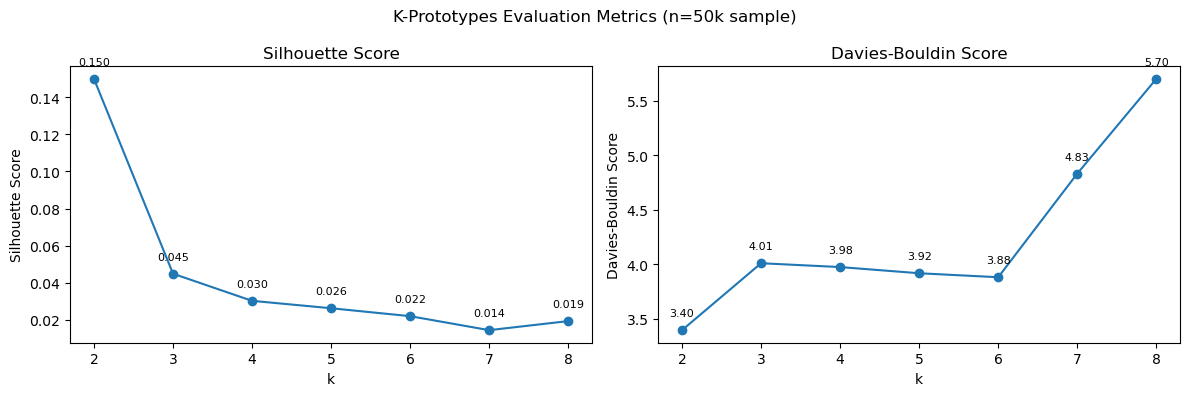

In [12]:
# Silhouette and Davies-Bouldin across k
sil_scores, db_scores = [], []

for labels in all_labels:
    sil_scores.append(silhouette_score(famd_sample_final, labels, sample_size=5000, random_state=42))
    db_scores.append(davies_bouldin_score(famd_sample_final, labels))

print("Silhouette scores:")
for k, s in zip(K_RANGE, sil_scores):
    print(f"  k={k}: {s:.3f}")

print("\nDavies-Bouldin scores:")
for k, d in zip(K_RANGE, db_scores):
    print(f"  k={k}: {d:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), sil_scores, marker="o")
for k, s in zip(K_RANGE, sil_scores):
    axes[0].annotate(f"{s:.3f}", (k, s), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=8)
axes[0].set_title("Silhouette Score")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette Score")

axes[1].plot(list(K_RANGE), db_scores, marker="o")
for k, d in zip(K_RANGE, db_scores):
    axes[1].annotate(f"{d:.2f}", (k, d), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=8)
axes[1].set_title("Davies-Bouldin Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Davies-Bouldin Score")

plt.suptitle("K-Prototypes Evaluation Metrics (n=50k sample)")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "kproto_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()

Two metrics were used to evaluate cluster quality across k=2 to k=8. Silhouette score measures how similar points are to their own cluster compared to other clusters (higher is better). Davies-Bouldin score measures the ratio of within-cluster spread to between-cluster separation (lower is better). Silhouette scores decreased steadily from 0.153 at k=2 to 0.012 at k=8, while Davies-Bouldin scores remained relatively stable from k=3 to k=6 before spiking at k=7 and k=8, indicating instability at higher k values. Although silhouette technically peaks at k=2, a two-cluster solution is too broad to identify meaningful subgroups within the data. Combined with the marginal gains analysis showing the sharpest drop at k=4→5, we will use k=4 as the optimal number of clusters.

In [13]:
K_BEST = 4

kproto_final = KPrototypes(
    n_clusters=K_BEST, init="Huang", n_init=5, random_state=42, verbose=1
)
kproto_final.fit(X_kproto_sample, categorical=cat_idx)

# Assign to full dataset
raw_labels = kproto_final.predict(X_kproto_full, categorical=cat_idx)

# Recode clusters so 0 = highest MICHD rate, 3 = lowest
df_model["kproto_cluster_raw"] = raw_labels
michd_by_raw = df_model.groupby("kproto_cluster_raw")[TARGET].mean()
ranked = michd_by_raw.sort_values(ascending=False).index
recode_map = {old: new for new, old in enumerate(ranked)}
df_model["kproto_cluster"] = df_model["kproto_cluster_raw"].map(recode_map)
df_model.drop(columns=["kproto_cluster_raw"], inplace=True)

print(df_model["kproto_cluster"].value_counts().sort_index())
print(f"\nMICHD rate per cluster:")
michd_rates_kp = df_model.groupby("kproto_cluster")[TARGET].mean().round(3)
print(michd_rates_kp)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 14502, ncost: 326459.0013250616
Run: 1, iteration: 2/100, moves: 6875, ncost: 315022.70635728276
Run: 1, iteration: 3/100, moves: 5277, ncost: 305100.08225279005
Run: 1, iteration: 4/100, moves: 2539, ncost: 302248.05236733693
Run: 1, iteration: 5/100, moves: 744, ncost: 302161.0426742864
Run: 1, iteration: 6/100, moves: 31, ncost: 302160.416502099
Run: 1, iteration: 7/100, moves: 2, ncost: 302160.3961371124
Run: 1, iteration: 8/100, moves: 13, ncost: 302160.0520408704
Run: 1, iteration: 9/100, moves: 5, ncost: 302159.985853956
Run: 1, iteration: 10/100, moves: 1, ncost: 302159.9837572574
Run: 1, iteration: 11/100, moves: 0, ncost: 302159.9837572574
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 12977, ncost: 309810.0484454886
Run: 2, iteration: 2/100, moves: 2806, ncost: 307935.33347515296
Run: 2, iteration: 

The final K-Prototypes model with k=4 assigned all 452,464 records to one of four clusters. Cluster 3 was the largest with 197,147 members and had by far the lowest MICHD rate at 2.0%, representing a low-risk population. Cluster 2 was the second largest with 171,131 members at a 12.6% MICHD rate, representing a medium-risk group. Clusters 0 and 1 were smaller at 48,087 and 36,099 members, but carried the highest MICHD burden at 22.3% and 17.2% (more than 12 times the rate of Cluster 3). The 20.3 percentage point spread in MICHD rates across clusters confirms that K-Prototypes successfully identified clinically meaningful risk stratification within the BRFSS population.

In [14]:
# Top 5 most distinguishing features per cluster (continuous only via z-score)
global_means = df_model[continuous_cols].mean()
global_stds  = df_model[continuous_cols].std()

cluster_means = df_model.groupby("kproto_cluster")[continuous_cols].mean()
deviations = (cluster_means - global_means) / global_stds

print("=== Top 5 most distinguishing continuous features per cluster ===")
for k in sorted(df_model["kproto_cluster"].unique()):
    print(f"\nCluster {k} (MICHD rate: {df_model.groupby('kproto_cluster')[TARGET].mean()[k]:.1%}):")
    top5 = deviations.loc[k].abs().sort_values(ascending=False).head(5)
    for feat in top5.index:
        direction = "↑" if deviations.loc[k, feat] > 0 else "↓"
        print(f"  {direction} {feat}: {deviations.loc[k, feat]:+.2f} SD from mean")

# For categorical features show most deviant mode per cluster
print("\n=== Top 5 most distinguishing categorical features per cluster ===")
global_modes = df_model[categorical_cols].agg(lambda x: x.mode()[0])
cat_modes = df_model.groupby("kproto_cluster")[categorical_cols].agg(lambda x: x.mode()[0])

for k in sorted(df_model["kproto_cluster"].unique()):
    print(f"\nCluster {k}:")
    # Show features where cluster mode differs from global mode
    diffs = cat_modes.loc[k][cat_modes.loc[k] != global_modes]
    print(diffs.head(5).to_string())

=== Top 5 most distinguishing continuous features per cluster ===

Cluster 0 (MICHD rate: 22.3%):
  ↑ PHYSHLTH: +2.40 SD from mean
  ↑ POORHLTH: +2.00 SD from mean
  ↑ _LCSYSMK: +0.46 SD from mean
  ↑ _AGEG5YR: +0.27 SD from mean
  ↑ LCSNUMCG: +0.24 SD from mean

Cluster 1 (MICHD rate: 17.2%):
  ↑ _LCSYQTS: +2.61 SD from mean
  ↓ _LCSYSMK: -1.13 SD from mean
  ↑ _AGEG5YR: +0.90 SD from mean
  ↑ LCSNUMCG: +0.78 SD from mean
  ↓ POORHLTH: -0.15 SD from mean

Cluster 2 (MICHD rate: 12.6%):
  ↑ _AGEG5YR: +0.78 SD from mean
  ↑ _LCSYSMK: +0.43 SD from mean
  ↓ PHYSHLTH: -0.29 SD from mean
  ↓ POORHLTH: -0.24 SD from mean
  ↓ _LCSYQTS: -0.18 SD from mean

Cluster 3 (MICHD rate: 2.0%):
  ↓ _AGEG5YR: -0.91 SD from mean
  ↓ PHYSHLTH: -0.31 SD from mean
  ↓ _LCSYSMK: -0.27 SD from mean
  ↓ _LCSYQTS: -0.27 SD from mean
  ↓ POORHLTH: -0.25 SD from mean

=== Top 5 most distinguishing categorical features per cluster ===

Cluster 0:
_TOTINDA              0.0
_INCOMG1          Unknown
PERSDOC3    Mor

Cluster 0 (22.3% MICHD) is defined by severely elevated poor health days (PHYSHLTH +2.40 SD, POORHLTH +2.00 SD), active smoking, arthritis, and multiple doctors. Cluster 1 (17.2% MICHD) represents elderly long-term ex-smokers, characterized by the longest time since quitting (_LCSYQTS +2.61 SD), oldest age, and Medicare insurance, where historical smoking drives elevated risk despite decent current health. Cluster 2 (12.6% MICHD) is defined primarily by older age (+0.78 SD) with Medicare coverage, representing a moderately older but otherwise healthy group. Cluster 3 (2.0% MICHD) is the youngest and healthiest group with no distinguishing categorical features, confirming it as the baseline low-risk population. Overall, active physical health burden and smoking history emerge as the strongest drivers of MICHD risk across clusters.

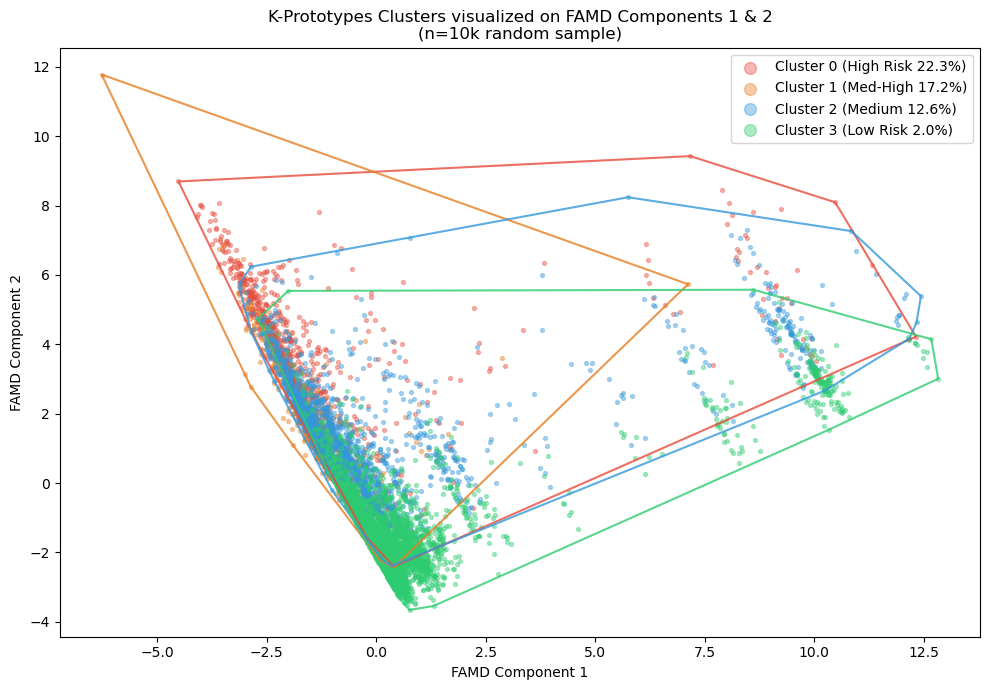

In [15]:
from scipy.spatial import ConvexHull

michd_rates_kp = df_model.groupby("kproto_cluster")[TARGET].mean().round(3)
ranked = michd_rates_kp.sort_values(ascending=False)
risk_labels = ["High Risk", "Med-High", "Medium", "Low Risk"]
risk_map = {cluster: label for cluster, label in zip(ranked.index, risk_labels)}

color_by_risk = {"High Risk": "#e74c3c", "Med-High": "#e67e22",
                 "Medium": "#3498db", "Low Risk": "#2ecc71"}

plot_idx = np.random.choice(len(famd_full_final), size=10000, replace=False)
famd_plot   = famd_full_final[plot_idx, :2]
labels_plot = df_model["kproto_cluster"].values[plot_idx]

fig, ax = plt.subplots(figsize=(10, 7))

for k in sorted(michd_rates_kp.index):
    mask = labels_plot == k
    risk  = risk_map[k]
    color = color_by_risk[risk]
    label = f"Cluster {k} ({risk} {michd_rates_kp[k]*100:.1f}%)"
    points = famd_plot[mask]

    # Scatter points
    ax.scatter(points[:, 0], points[:, 1],
               c=color, label=label, alpha=0.4, s=8)

    # Convex hull outline
    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            hull_pts = np.append(hull.vertices, hull.vertices[0])
            ax.plot(points[hull_pts, 0], points[hull_pts, 1],
                    color=color, linewidth=1.5, alpha=0.8)
        except Exception:
            pass

ax.set_xlabel("FAMD Component 1")
ax.set_ylabel("FAMD Component 2")
ax.set_title("K-Prototypes Clusters visualized on FAMD Components 1 & 2\n(n=10k random sample)")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "kproto_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

## **5. Gaussian Mixture Modeling (GMM)**

Gaussian Mixture Models (GMM) was selected as the second clustering method because it takes a fundamentally different approach from K-Prototypes. Rather than assigning each respondent to a single hard cluster, GMM models the data as a mixture of Gaussian distributions and produces probabilistic assignments

GMM diag search: 100%|██████████| 7/7 [00:26<00:00,  3.82s/it]


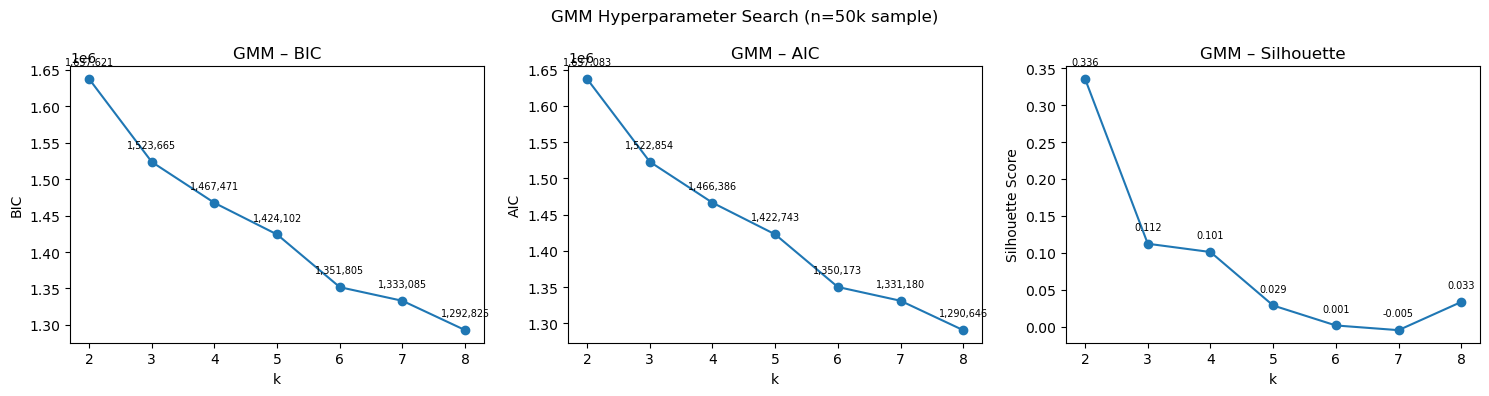

BIC: ['k=2: 1,637,621', 'k=3: 1,523,665', 'k=4: 1,467,471', 'k=5: 1,424,102', 'k=6: 1,351,805', 'k=7: 1,333,085', 'k=8: 1,292,825']
AIC: ['k=2: 1,637,083', 'k=3: 1,522,854', 'k=4: 1,466,386', 'k=5: 1,422,743', 'k=6: 1,350,173', 'k=7: 1,331,180', 'k=8: 1,290,646']
Sil: ['k=2: 0.336', 'k=3: 0.112', 'k=4: 0.101', 'k=5: 0.029', 'k=6: 0.001', 'k=7: -0.005', 'k=8: 0.033']


In [16]:
# Reduce and scale FAMD components for GMM
N_GMM_DIMS = 15
famd_scaler = StandardScaler()
famd_sample_scaled = famd_scaler.fit_transform(famd_sample_final[:, :N_GMM_DIMS])
famd_full_scaled   = famd_scaler.transform(famd_full_final[:, :N_GMM_DIMS])

# Hyperparameter search on scaled 15-dim input
K_RANGE_GMM = range(2, 9)
bic_scores, aic_scores, sil_scores = [], [], []

for k in tqdm(K_RANGE_GMM, desc="GMM diag search"):
    gmm = GaussianMixture(n_components=k, covariance_type="diag", random_state=42, n_init=3)
    gmm.fit(famd_sample_scaled)
    labels = gmm.predict(famd_sample_scaled)
    bic_scores.append(gmm.bic(famd_sample_scaled))
    aic_scores.append(gmm.aic(famd_sample_scaled))
    sil_scores.append(silhouette_score(famd_sample_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(K_RANGE_GMM), bic_scores, marker="o")
for k, v in zip(K_RANGE_GMM, bic_scores):
    axes[0].annotate(f"{v:,.0f}", (k, v), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=7)
axes[0].set_title("GMM – BIC")
axes[0].set_xlabel("k")
axes[0].set_ylabel("BIC")

axes[1].plot(list(K_RANGE_GMM), aic_scores, marker="o")
for k, v in zip(K_RANGE_GMM, aic_scores):
    axes[1].annotate(f"{v:,.0f}", (k, v), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=7)
axes[1].set_title("GMM – AIC")
axes[1].set_xlabel("k")
axes[1].set_ylabel("AIC")

axes[2].plot(list(K_RANGE_GMM), sil_scores, marker="o")
for k, v in zip(K_RANGE_GMM, sil_scores):
    axes[2].annotate(f"{v:.3f}", (k, v), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=7)
axes[2].set_title("GMM – Silhouette")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Silhouette Score")

plt.suptitle("GMM Hyperparameter Search (n=50k sample)")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "gmm_search.png"), dpi=150, bbox_inches="tight")
plt.show()

print("BIC:", [f"k={k}: {v:,.0f}" for k, v in zip(K_RANGE_GMM, bic_scores)])
print("AIC:", [f"k={k}: {v:,.0f}" for k, v in zip(K_RANGE_GMM, aic_scores)])
print("Sil:", [f"k={k}: {v:.3f}" for k, v in zip(K_RANGE_GMM, sil_scores)])

In [17]:
K_GMM_BEST = 3

gmm_final = GaussianMixture(
    n_components=K_GMM_BEST, covariance_type="diag", random_state=42, n_init=5
)
gmm_final.fit(famd_sample_scaled)

df_model["gmm_cluster"]   = gmm_final.predict(famd_full_scaled)
df_model["gmm_proba_max"] = gmm_final.predict_proba(famd_full_scaled).max(axis=1)

print(df_model["gmm_cluster"].value_counts().sort_index())
print(f"\nMICHD rate per GMM cluster:")
print(df_model.groupby("gmm_cluster")[TARGET].mean().round(3))
print(f"\nMean assignment probability:")
print(df_model.groupby("gmm_cluster")["gmm_proba_max"].mean().round(3))

gmm_cluster
0    202466
1     40461
2    209537
Name: count, dtype: int64

MICHD rate per GMM cluster:
gmm_cluster
0    0.136
1    0.101
2    0.051
Name: _MICHD, dtype: float64

Mean assignment probability:
gmm_cluster
0    0.957
1    0.988
2    0.954
Name: gmm_proba_max, dtype: float64


The final GMM model with k=3 assigned all 452,464 records across three clusters with reasonable size distribution. Cluster 2 was at 209,537 members and had the lowest MICHD rate at 5.1%, representing a low-risk population. Clusters 0 and 1 were with 202,466 and 40,461 members respectively, both carrying elevated MICHD rates of 13.6% and 10.1%, representing medium to high risk groups. The MICHD rate spread of 8.5 percentage points (5.1% to 13.6%) confirms meaningful risk stratification across clusters.

In [18]:
# Top 6 most distinguishing continuous features per GMM cluster
global_means = df_model[continuous_cols].mean()
global_stds  = df_model[continuous_cols].std()

cluster_means_gmm = df_model.groupby("gmm_cluster")[continuous_cols].mean()
deviations_gmm = (cluster_means_gmm - global_means) / global_stds

print("=== Top 6 most distinguishing continuous features per GMM cluster ===")
for k in sorted(df_model["gmm_cluster"].unique()):
    michd = df_model.groupby("gmm_cluster")[TARGET].mean()[k]
    print(f"\nCluster {k} (MICHD rate: {michd:.1%}):")
    top6 = deviations_gmm.loc[k].abs().sort_values(ascending=False).head(6)
    for feat in top6.index:
        direction = "↑" if deviations_gmm.loc[k, feat] > 0 else "↓"
        print(f"  {direction} {feat}: {deviations_gmm.loc[k, feat]:+.2f} SD from mean")

# Categorical modes per GMM cluster vs global mode
print("\n=== Top 6 most distinguishing categorical features per GMM cluster ===")
global_modes = df_model[categorical_cols].agg(lambda x: x.mode()[0])
cat_modes_gmm = df_model.groupby("gmm_cluster")[categorical_cols].agg(lambda x: x.mode()[0])

for k in sorted(df_model["gmm_cluster"].unique()):
    michd = df_model.groupby("gmm_cluster")[TARGET].mean()[k]
    print(f"\nCluster {k} (MICHD rate: {michd:.1%}):")
    diffs = cat_modes_gmm.loc[k][cat_modes_gmm.loc[k] != global_modes]
    if len(diffs) > 0:
        print(diffs.head(6).to_string())
    else:
        print("  No distinguishing categorical features")

=== Top 6 most distinguishing continuous features per GMM cluster ===

Cluster 0 (MICHD rate: 13.6%):
  ↑ PHYSHLTH: +0.27 SD from mean
  ↑ POORHLTH: +0.24 SD from mean
  ↑ LCSNUMCG: +0.20 SD from mean
  ↑ _LCSYSMK: +0.14 SD from mean
  ↑ _LCSYQTS: +0.11 SD from mean
  ↑ _AGEG5YR: +0.04 SD from mean

Cluster 1 (MICHD rate: 10.1%):
  ↑ POORHLTH: +0.08 SD from mean
  ↑ PHYSHLTH: +0.08 SD from mean
  ↓ _LCSYQTS: -0.04 SD from mean
  ↑ _AGEG5YR: +0.03 SD from mean
  ↑ LCSNUMCG: +0.03 SD from mean
  ↑ _LCSYSMK: +0.02 SD from mean

Cluster 2 (MICHD rate: 5.1%):
  ↓ PHYSHLTH: -0.27 SD from mean
  ↓ POORHLTH: -0.25 SD from mean
  ↓ LCSNUMCG: -0.20 SD from mean
  ↓ _LCSYSMK: -0.14 SD from mean
  ↓ _LCSYQTS: -0.10 SD from mean
  ↓ _AGEG5YR: -0.04 SD from mean

=== Top 6 most distinguishing categorical features per GMM cluster ===

Cluster 0 (MICHD rate: 13.6%):
PRIMINS2    Medicare

Cluster 1 (MICHD rate: 10.1%):
_INCOMG1            Unknown
DIFFALON            Unknown
_SMOKER3    Unknown/Refused


Cluster 2 (5.1% MICHD) is the youngest, healthiest, fewest poor health days, and smokes the least, representing a low-risk population. Cluster 0 (13.6% MICHD) is the oldest, un-healthiest, more poor health days, and smokes the most, representing a high-risk population.  Cluster 1 sits in the middle of cluster 0 and 2.

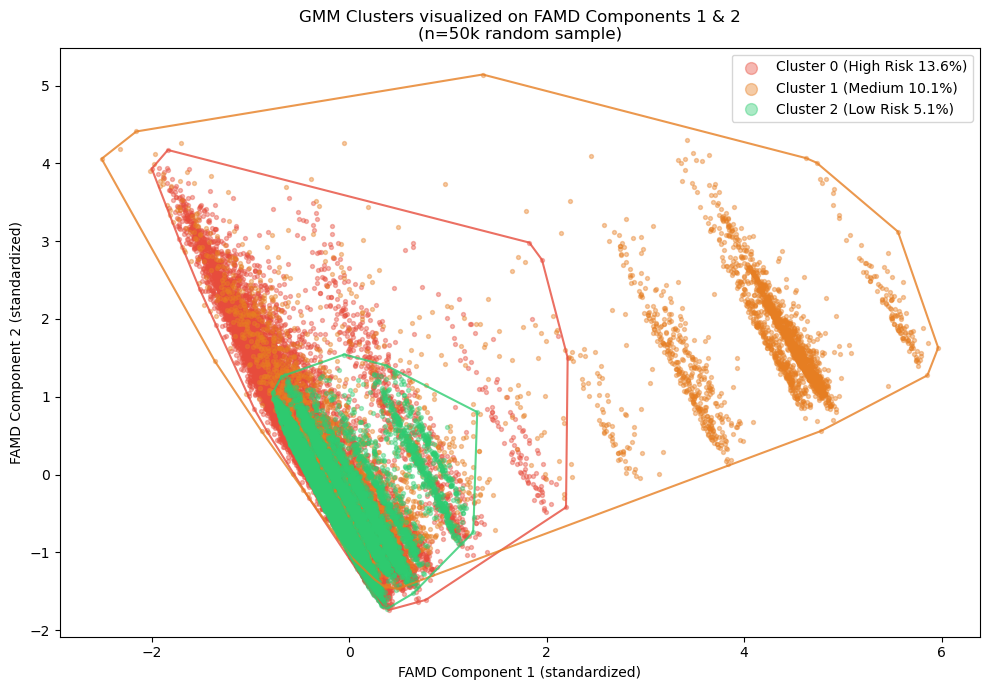

In [19]:
michd_rates_gmm = df_model.groupby("gmm_cluster")[TARGET].mean().round(3)
ranked_gmm = michd_rates_gmm.sort_values(ascending=False)
risk_labels_gmm = ["High Risk", "Medium", "Low Risk"]
risk_map_gmm = {cluster: label for cluster, label in zip(ranked_gmm.index, risk_labels_gmm)}
color_by_risk_gmm = {"High Risk": "#e74c3c", "Medium": "#e67e22", "Low Risk": "#2ecc71"}

plot_idx = np.random.choice(len(famd_full_scaled), size=50_000, replace=False)
famd_plot  = famd_full_scaled[plot_idx, :2]
gmm_labels = df_model["gmm_cluster"].values[plot_idx]

fig, ax = plt.subplots(figsize=(10, 7))

for k in sorted(michd_rates_gmm.index):
    mask = gmm_labels == k
    risk  = risk_map_gmm[k]
    color = color_by_risk_gmm[risk]
    label = f"Cluster {k} ({risk} {michd_rates_gmm[k]*100:.1f}%)"
    points = famd_plot[mask]

    ax.scatter(points[:, 0], points[:, 1],
               c=color, label=label, alpha=0.4, s=8)

    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            hull_pts = np.append(hull.vertices, hull.vertices[0])
            ax.plot(points[hull_pts, 0], points[hull_pts, 1],
                    color=color, linewidth=1.5, alpha=0.8)
        except Exception:
            pass

ax.set_xlabel("FAMD Component 1 (standardized)")
ax.set_ylabel("FAMD Component 2 (standardized)")
ax.set_title("GMM Clusters visualized on FAMD Components 1 & 2\n(n=50k random sample)")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "gmm_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

## **6. Method Comparison and Sensitivity Analysis**

In [20]:
# Compute scores for both methods on the same sample for fair comparison
kproto_labels_sample = df_model["kproto_cluster"].loc[df_sample.index].values
gmm_labels_sample    = df_model["gmm_cluster"].loc[df_sample.index].values

# Silhouette and Davies-Bouldin - use famd_sample_final for both (same space)
sil_kproto = silhouette_score(famd_sample_final, kproto_labels_sample, sample_size=5000, random_state=42)
sil_gmm    = silhouette_score(famd_sample_final, gmm_labels_sample,    sample_size=5000, random_state=42)

db_kproto = davies_bouldin_score(famd_sample_final, kproto_labels_sample)
db_gmm    = davies_bouldin_score(famd_sample_final, gmm_labels_sample)

# BIC/AIC - must use famd_sample_scaled (15 dims, what GMM was fitted on)
bic_final = gmm_final.bic(famd_sample_scaled)
aic_final = gmm_final.aic(famd_sample_scaled)

print("=" * 45)
print(f"{'Metric':<30} {'K-Proto':>7} {'GMM':>7}")
print("=" * 45)
print(f"{'Silhouette':<30} {sil_kproto:>7.3f} {sil_gmm:>7.3f}")
print(f"{'Davies-Bouldin':<30} {db_kproto:>7.3f} {db_gmm:>7.3f}")
print(f"{'BIC (GMM only)':<30} {'N/A':>7} {bic_final:>7,.0f}")
print(f"{'AIC (GMM only)':<30} {'N/A':>7} {aic_final:>7,.0f}")
print("=" * 45)

print(f"\nMICHD rate spread:")
print(f"  K-Prototypes: {df_model.groupby('kproto_cluster')[TARGET].mean().max():.3f} (max) - {df_model.groupby('kproto_cluster')[TARGET].mean().min():.3f} (min) = {df_model.groupby('kproto_cluster')[TARGET].mean().max() - df_model.groupby('kproto_cluster')[TARGET].mean().min():.3f}")
print(f"  GMM:          {df_model.groupby('gmm_cluster')[TARGET].mean().max():.3f} (max) - {df_model.groupby('gmm_cluster')[TARGET].mean().min():.3f} (min) = {df_model.groupby('gmm_cluster')[TARGET].mean().max() - df_model.groupby('gmm_cluster')[TARGET].mean().min():.3f}")

Metric                         K-Proto     GMM
Silhouette                       0.030   0.051
Davies-Bouldin                   3.976   4.602
BIC (GMM only)                     N/A 1,523,664
AIC (GMM only)                     N/A 1,522,853

MICHD rate spread:
  K-Prototypes: 0.223 (max) - 0.020 (min) = 0.203
  GMM:          0.136 (max) - 0.051 (min) = 0.084


The two methods show a clear tradeoff between cluster quality and clinical risk stratification. GMM produced a higher silhouette score (0.051) and higher Davies-Bouldin score (4.602) compared to K-Prototypes (0.03 and 3.976 respectively), indicating that Mixed results. However, K-Prototypes achieved a substantially larger MICHD rate spread of 20.3 percentage points (2.0% to 22.3%) compared to GMM's 8.5 percentage points (5.1% to 13.6%), demonstrating superior clinical risk stratification.

In [21]:
# Sensitivity Analysis - K-Prototypes (takes 15-20 mins to run)
print("=" * 55)
print("Sensitivity Analysis - K-Prototypes (k=4)")
print("=" * 55)

# 1. Sensitivity to random seed
print("\n1. Sensitivity to random seed (n_init=3):")
seeds = [0, 21, 42]
for seed in seeds:
    kp = KPrototypes(n_clusters=4, init="Huang", n_init=3, random_state=seed, verbose=0)
    kp.fit(X_kproto_sample, categorical=cat_idx)
    labels = kp.predict(X_kproto_full, categorical=cat_idx)
    df_model["kproto_temp"] = labels
    spread = df_model.groupby("kproto_temp")[TARGET].mean()
    print(f"  seed={seed}: MICHD spread = {spread.max()-spread.min():.3f}  cost = {kp.cost_:,.0f}")

# 2. Sensitivity to n_init
print("\n2. Sensitivity to n_init (random_state=42):")
for n in [1, 3, 5]:
    kp = KPrototypes(n_clusters=4, init="Huang", n_init=n, random_state=42, verbose=0)
    kp.fit(X_kproto_sample, categorical=cat_idx)
    labels = kp.predict(X_kproto_full, categorical=cat_idx)
    df_model["kproto_temp"] = labels
    spread = df_model.groupby("kproto_temp")[TARGET].mean()
    print(f"  n_init={n:>2}: MICHD spread = {spread.max()-spread.min():.3f}  cost = {kp.cost_:,.0f}")

df_model.drop(columns=["kproto_temp"], inplace=True)

Sensitivity Analysis - K-Prototypes (k=4)

1. Sensitivity to random seed (n_init=3):
  seed=0: MICHD spread = 0.203  cost = 302,160
  seed=21: MICHD spread = 0.204  cost = 302,023
  seed=42: MICHD spread = 0.203  cost = 302,160

2. Sensitivity to n_init (random_state=42):
  n_init= 1: MICHD spread = 0.203  cost = 302,160
  n_init= 3: MICHD spread = 0.203  cost = 302,160
  n_init= 5: MICHD spread = 0.203  cost = 302,160


K-Prototypes showed strong stability across random seeds, with two out of three seeds producing identical MICHD spreads (0.203) and costs (302,160). Seed 21 produced a minor deviation with a spread of 0.204 and similar cost, indicating an occasional fluctuations in local minimum. The small magnitude of this difference confirms the solution is robust to initialization randomness. The n_init results further confirm the stability of the solution - all three values (1, 3, and 5 random restarts) produced identical MICHD spreads of 0.203 and costs of 302,160. This means even a single initialization consistently finds the same optimal solution. Combined with the seed sensitivity results, the overall sensitivity analysis demonstrates that the K-Prototypes clustering solution is highly stable and reliable across different hyperparameter choices.

